In [2]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Customer.csv")
print(df.head())

# Use common customer segmentation columns when available
preferred = ["Annual Income (k$)", "Spending Score (1-100)"]
features = [col for col in preferred if col in df.columns]

# Otherwise, use all numeric columns
if len(features) < 2:
    features = df.select_dtypes(include="number").columns.tolist()

X = df[features].dropna()

# Scale features
X_scaled = StandardScaler().fit_transform(X)

# Build KMeans model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)


   CustomerID  Annual_Income_k  Spending_Score
0        1062               25              88
1        1058               30              75
2        1011               22              25
3        1180               80              74
4        1097               55              43


In [3]:
y_pred = kmeans.fit_predict(X_scaled)

In [4]:
y_pred

array([2, 2, 2, 0, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 2,
       2, 1, 0, 1, 1, 2, 2, 0, 1, 0, 1, 2, 2, 2, 0, 2, 1, 0, 1, 0, 2, 1,
       2, 0, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 0, 2, 1, 2, 2, 1, 1, 0, 2, 2,
       2, 1, 1, 0, 1, 2, 2, 1, 1, 2, 2, 0, 1, 2, 2, 1, 2, 0, 2, 1, 2, 0,
       1, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 1, 2, 1, 0, 1, 2, 1, 1, 2, 2,
       2, 1, 1, 0, 2, 2, 1, 0, 2, 0, 0, 1, 1, 1, 0, 1, 2, 1, 1, 0, 0, 0,
       2, 2, 2, 2, 1, 2, 0, 2, 0, 1, 1, 1, 2, 2, 2, 2, 1, 1, 0, 2, 1, 2,
       2, 1, 0, 1, 2, 1, 0, 2, 0, 2, 2, 2, 1, 0, 1, 0, 1, 2, 2, 0, 2, 2,
       2, 1, 2, 0, 2, 2, 1, 2, 1, 1, 1, 0, 2, 2, 0, 2, 1, 1, 1, 2, 2, 1,
       1, 1], dtype=int32)

## For Display Purpose

          CustomerID  Annual_Income_k  Spending_Score
Cluster                                              
0.0      1180.500000        84.325000       81.700000
1.0      1122.693333        69.666667       37.173333
2.0      1043.270588        27.152941       50.517647


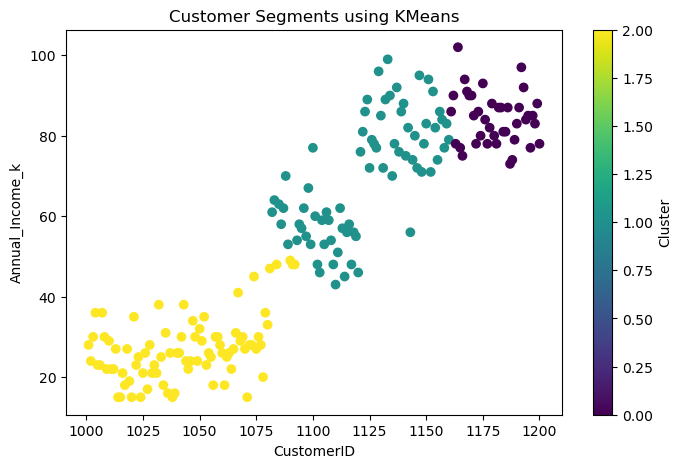

In [5]:
df.loc[X.index, "Cluster"] = kmeans.fit_predict(X_scaled)
print(df.groupby("Cluster")[features].mean())

# Visualize the first two features
plt.figure(figsize=(8, 5))
plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=df.loc[X.index, "Cluster"],
    cmap="viridis"
)
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("Customer Segments using KMeans")
plt.colorbar(label="Cluster")
plt.show()